# Hotel Booking — Predicción de Cancelaciones

**Proyecto:** Clasificación binaria para predecir si una reserva hotelera será cancelada.  
**Dataset:** Reservas hoteleras 2015–2017 (~119.000 registros).  
**Objetivo:** Entrenar un modelo capaz de anticipar cancelaciones y apoyar la toma de decisiones operativas del hotel.

---

## Contexto del negocio

Las cancelaciones de reservas representan un desafío para la industria hotelera: generan pérdidas en los ingresos, provocan una mala planificación en la ocupación y derivan en sobrecostes operativos. Aproximadamente el **37% de las reservas del dataset son cancelaciones**, lo que pone de manifiesto la relevancia del problema.

El enfoque adoptado es de **clasificación supervisada binaria**: disponemos de variables predictoras históricas y una variable objetivo conocida (`is_canceled`). Esto permite entrenar modelos que estimen la probabilidad de cancelación para nuevas reservas y guíen decisiones operativas.

El objetivo de este estudio es desarrollar un modelo de clasificación binaria capaz de predecir con antelación la probabildiad de cancelación de una reserva, permitiendo a los hoteles elaborar estrategias de actuación que reduzcan el impacto económico y operativo de las cancelaciones, apoyándose en datos históricos.

---


## **Paso 1: Importación de librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## **Paso 2: Carga y exploración inicial de los datos**

In [11]:
df = pd.read_csv("src/data_sample/hotel_booking.csv", sep=",")

print(f"Shape del dataset: {df.shape}")
df.head(5)

Shape del dataset: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [13]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [14]:
print("Valores nulos por columna:")
df.isna().sum()[df.isna().sum() > 0]

Valores nulos por columna:


children         4
country        488
agent        16340
company     112593
dtype: int64

In [15]:
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 0


**Observaciones:**
- El dataset tiene **119.390 filas y 36 columnas** inicialmente.
- Existen **4 columnas con valores nulos**: `children`, `country`, `agent` y `company`.
- **No existen filas duplicadas.**
- Columnas como `name`, `email`, `phone-number` y `credit_card` no aportan valor predictivo.
- Las variables `reservation_status` y `reservation_status_date` son **data leakage**: contienen información obtenida después del resultado de la reserva y deben eliminarse.

---
## **Paso 3: Limpieza del dataset y eliminación de columnas**



In [16]:
# Columnas a eliminar:
# - Datos personales (no predictivos): name, email, phone-number, credit_card
# - Data leakage: reservation_status, reservation_status_date
# - IDs con excesivos nulos y baja utilidad predictiva: agent, company

columns_to_drop = [
    "name", "email", "phone-number", "credit_card",
    "reservation_status", "reservation_status_date",
    "agent", "company"
]

df_hotel = df.drop(columns=columns_to_drop)

print(f"Shape tras limpieza: {df_hotel.shape}")
print(f"Columnas restantes: {list(df_hotel.columns)}")

Shape tras limpieza: (119390, 28)
Columnas restantes: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


---
## **Paso 4: Análisis del target (`is_canceled`)**

Distribución del target:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Proporción:
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


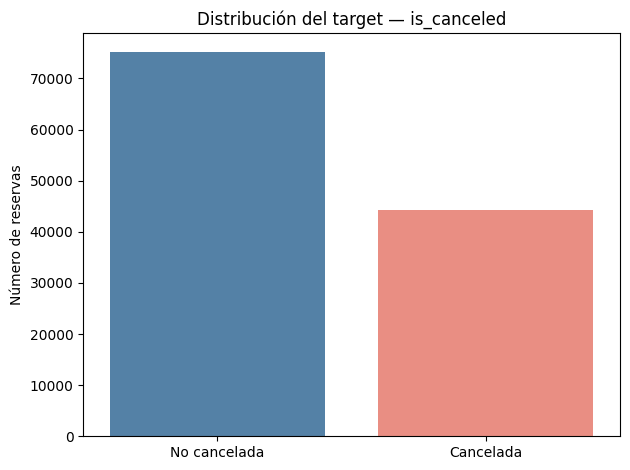

In [17]:
target = "is_canceled"

print("Distribución del target:")
print(df_hotel[target].value_counts())
print()
print("Proporción:")
print(df_hotel[target].value_counts(normalize=True).round(3))

# Visualización
labels = df_hotel[target].map({0: "No cancelada", 1: "Cancelada"})
sns.countplot(x=labels, palette=["steelblue", "salmon"])
plt.title("Distribución del target — is_canceled")
plt.ylabel("Número de reservas")
plt.xlabel("")
plt.tight_layout()
plt.show()

**Observación:** El 62% de las reservas no se cancelan frente al 37% que sí lo hace. El **desbalance es moderado** y se gestionará mediante `class_weight="balanced"` en los modelos.

---
## **Paso 5: División Train / Test**

In [18]:
X_raw = df_hotel.drop(columns=target)
y_raw = df_hotel[target]

# División inicial para separar test antes de cualquier transformación
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)

print(f"Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")
print(f"\nProporción target en train: {y_train.mean():.3f}")
print(f"Proporción target en test:  {y_test.mean():.3f}")

Train: (95512, 27)  |  Test: (23878, 27)

Proporción target en train: 0.370
Proporción target en test:  0.370


---
## **Paso 6: Selección de variables**

Basada en el análisis exploratorio previo (correlación con el target, relevancia de negocio y ausencia de data leakage).

In [19]:
cols_to_keep = [
    # Categóricas
    "hotel",
    "customer_type",
    "market_segment",
    "deposit_type",
    "meal",
    "country",
    "distribution_channel",
    "reserved_room_type",
    "is_repeated_guest",

    # Numéricas
    "lead_time",
    "previous_cancellations",
    "adults",
    "days_in_waiting_list",
    "adr",
    "previous_bookings_not_canceled",
    "booking_changes",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

X_train_sel = X_train_raw[cols_to_keep].copy()
X_test_sel  = X_test_raw[cols_to_keep].copy()

print(f"Variables seleccionadas: {len(cols_to_keep)}")
print(cols_to_keep)

Variables seleccionadas: 18
['hotel', 'customer_type', 'market_segment', 'deposit_type', 'meal', 'country', 'distribution_channel', 'reserved_room_type', 'is_repeated_guest', 'lead_time', 'previous_cancellations', 'adults', 'days_in_waiting_list', 'adr', 'previous_bookings_not_canceled', 'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests']


---
## **Paso 7: Feature Engineering**

Se crean nuevas variables derivadas para enriquecer el espacio de features y capturar patrones de comportamiento del cliente.

In [20]:
def feature_engineering(df_in):
    """Aplica todas las transformaciones de features sobre un DataFrame."""
    df = df_in.copy()

    # --- 1. Agrupación de país (174 valores → 4 grupos) ---
    europe  = ["PRT", "GBR", "ESP", "FRA", "DEU", "ITA"]
    america = ["USA", "BRA", "CAN"]
    asia    = ["CHN", "IND", "JPN"]

    def group_country(c):
        if c in europe:  return "Europe"
        if c in america: return "America"
        if c in asia:    return "Asia"
        return "Other"

    df["country_grouped"] = df["country"].apply(group_country)
    df = df.drop(columns=["country"])

    # --- 2. Transformaciones logarítmicas (reducir asimetría) ---
    df["adr"] = df["adr"].clip(lower=0) # Evitamos valores negativos (si los hubiera)
    df["adr_log"] = np.log1p(df["adr"]) # Aplicamos log(1+x) para reducir asimetría
    df["lead_time_log"] = np.log1p(df["lead_time"]) 
    df["previous_cancellations"] = np.log1p(df["previous_cancellations"])
    df = df.drop(columns=["adr"])   # se sustituye por adr_log

    # --- 3. Nuevas features derivadas ---
    # Historial de cancelación
    df["had_previous_cancel"] = (df["previous_cancellations"] > 0).astype(int)

    # Ratio de cancelaciones históricas
    df["cancel_ratio"] = (
        df["previous_cancellations"]
        / (df["previous_cancellations"] + df["previous_bookings_not_canceled"] + 1)
    )

    # Cliente fiel sin historial de cancelación
    df["loyal_customer"] = (
        (df["is_repeated_guest"] == 1) & (df["previous_cancellations"] == 0)
    ).astype(int)

    # Interacción lead_time × adr
    df["lead_time_x_adr"] = df["lead_time_log"] * df["adr_log"]

    # Alta demanda de solicitudes especiales (≥2)
    df["many_special_requests"] = (df["total_of_special_requests"] >= 2).astype(int)

    # Necesita parking
    df["needs_parking"] = (df["required_car_parking_spaces"] > 0).astype(int)

    # Lead time alto (sobre la mediana del train)
    df["long_lead"] = (df["lead_time"] > df["lead_time"].median()).astype(int)

    # Normalizar categoría Undefined en market_segment
    df["market_segment"] = df["market_segment"].replace("Undefined", "Other")

    return df


X_train = feature_engineering(X_train_sel)
X_test  = feature_engineering(X_test_sel)

print(f"Shape tras feature engineering — Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nNuevas features: {[c for c in X_train.columns if c not in cols_to_keep]}")

Shape tras feature engineering — Train: (95512, 26)  |  Test: (23878, 26)

Nuevas features: ['country_grouped', 'adr_log', 'lead_time_log', 'had_previous_cancel', 'cancel_ratio', 'loyal_customer', 'lead_time_x_adr', 'many_special_requests', 'needs_parking', 'long_lead']


---
## **Paso 8: Construcción del preprocesador (Pipeline)**

Se construyen pipelines diferenciados para variables numéricas y categóricas, encadenados en un `ColumnTransformer`.

- **Numéricas:** imputación por mediana + escalado estándar (`StandardScaler`).
- **Categóricas:** imputación por moda + codificación One-Hot.

In [21]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Variables numéricas ({len(num_cols)}): {num_cols}")
print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

print("\n Preprocesador construido.")

Variables numéricas (18): ['is_repeated_guest', 'lead_time', 'previous_cancellations', 'adults', 'days_in_waiting_list', 'previous_bookings_not_canceled', 'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests', 'adr_log', 'lead_time_log', 'had_previous_cancel', 'cancel_ratio', 'loyal_customer', 'lead_time_x_adr', 'many_special_requests', 'needs_parking', 'long_lead']
Variables categóricas (8): ['hotel', 'customer_type', 'market_segment', 'deposit_type', 'meal', 'distribution_channel', 'reserved_room_type', 'country_grouped']

 Preprocesador construido.


---
## **Paso 9: Modelo baseline — Regresión Logística**

Se entrena un modelo de regresión logística como baseline de referencia para establecer el rendimiento mínimo esperado.

In [22]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

bal_acc_log = balanced_accuracy_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, y_proba_log)

print("── Regresión Logística (Baseline) ──")
print(f"Balanced Accuracy: {bal_acc_log:.4f}")
print(f"ROC-AUC: {roc_auc_log:.4f}")
print()
print(classification_report(y_test, y_pred_log, target_names=["No cancelada", "Cancelada"]))

── Regresión Logística (Baseline) ──
Balanced Accuracy: 0.7754
ROC-AUC: 0.8662

              precision    recall  f1-score   support

No cancelada       0.84      0.83      0.83     15033
   Cancelada       0.71      0.72      0.72      8845

    accuracy                           0.79     23878
   macro avg       0.77      0.78      0.77     23878
weighted avg       0.79      0.79      0.79     23878



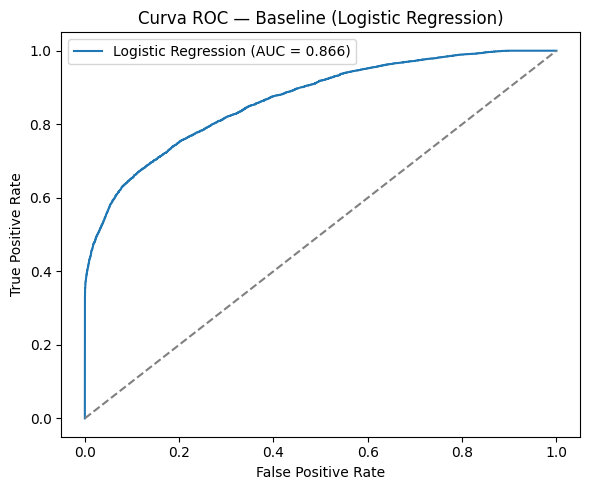

In [23]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Baseline (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.show()

---
## **Paso 10: Comparativa de modelos candidatos**

Se evalúan 4 modelos usando el mismo preprocesador para identificar el mejor candidato antes de la optimización de hiperparámetros.

In [24]:
# ── Random Forest ──────────────────────────────────────────
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
print("[1/3] Random Forest — entrenado")

# ── Gradient Boosting ──────────────────────────────────────
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])
gb_pipe.fit(X_train, y_train)
y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]
print("[2/3] Gradient Boosting — entrenado")

# ── KNN ────────────────────────────────────────────────────
knn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])
knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
y_proba_knn = knn_pipe.predict_proba(X_test)[:, 1]
print("[3/3] KNN — entrenado")

[1/3] Random Forest — entrenado
[2/3] Gradient Boosting — entrenado
[3/3] KNN — entrenado


In [25]:
comparison = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "Gradient Boosting", "KNN"],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_log),
        balanced_accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_gb),
        balanced_accuracy_score(y_test, y_pred_knn)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gb),
        roc_auc_score(y_test, y_proba_knn)
    ]
}).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

comparison["Balanced Accuracy"] = comparison["Balanced Accuracy"].round(4)
comparison["ROC-AUC"] = comparison["ROC-AUC"].round(4)

print("Tabla comparativa de modelos candidatos:")
comparison

Tabla comparativa de modelos candidatos:


,Modelo,Balanced Accuracy,ROC-AUC
0,Random Forest,0.8302,0.9194
1,KNN,0.8065,0.8997
2,Gradient Boosting,0.7763,0.8848
3,Logistic Regression,0.7754,0.8662


**Conclusión:** **Random Forest** obtiene el mejor ROC-AUC y Balanced Accuracy entre los modelos candidatos. Se selecciona para la fase de optimización de hiperparámetros.

---
## **Paso 11: Optimización de hiperparámetros — GridSearchCV con validación cruzada**

Se realiza una búsqueda exhaustiva de hiperparámetros sobre Random Forest mediante validación cruzada estratificada (5 folds), optimizando `balanced_accuracy`.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe_opt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [8, 12, 16],
    "model__min_samples_split":[5, 10],
    "model__min_samples_leaf": [2, 5],
    "model__max_features":["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=rf_pipe_opt,
    param_grid=param_grid,
    scoring={
        "bal_acc": "balanced_accuracy",
        "roc_auc": "roc_auc"
    },
    refit="bal_acc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nGridSearchCV completado.")
print(f"Mejores hiperparámetros: {grid.best_params_}")
print(f"Mejor Balanced Accuracy en CV: {grid.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

 GridSearchCV completado.
Mejores hiperparámetros: {'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Mejor Balanced Accuracy en CV: 0.8181


---
## **Paso 12: Evaluación del modelo optimizado en Train vs Test**

Se verifica que el modelo no presente overfitting comparando métricas en train y test.

In [27]:
best_model = grid.best_estimator_

# Predicciones
y_pred_train_opt  = best_model.predict(X_train)
y_proba_train_opt = best_model.predict_proba(X_train)[:, 1]

y_pred_opt  = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

# Métricas
train_bal = balanced_accuracy_score(y_train, y_pred_train_opt)
train_auc = roc_auc_score(y_train, y_proba_train_opt)
test_bal  = balanced_accuracy_score(y_test,  y_pred_opt)
test_auc  = roc_auc_score(y_test,  y_proba_opt)

overfitting = pd.DataFrame({
    "Conjunto": ["Train", "Test"],
    "Balanced Accuracy": [round(train_bal, 4), round(test_bal, 4)],
    "ROC-AUC": [round(train_auc, 4), round(test_auc, 4)]
})

print("Comparativa Train vs Test — Modelo Optimizado:")
overfitting

Comparativa Train vs Test — Modelo Optimizado:


,Conjunto,Balanced Accuracy,ROC-AUC
0,Train,0.8328,0.9262
1,Test,0.8166,0.9079


---
## **Paso 13: Evaluación contra Test — Métricas finales del modelo optimizado**

In [28]:
print("══════════════════════════════════════════════")
print("  EVALUACIÓN FINAL — Random Forest Optimizado")
print("══════════════════════════════════════════════")
print(f"Balanced Accuracy : {test_bal:.4f}")
print(f"ROC-AUC: {test_auc:.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=["No cancelada", "Cancelada"]))

══════════════════════════════════════════════
  EVALUACIÓN FINAL — Random Forest Optimizado
══════════════════════════════════════════════
Balanced Accuracy : 0.8166
ROC-AUC: 0.9079

              precision    recall  f1-score   support

No cancelada       0.86      0.88      0.87     15033
   Cancelada       0.79      0.75      0.77      8845

    accuracy                           0.83     23878
   macro avg       0.82      0.82      0.82     23878
weighted avg       0.83      0.83      0.83     23878



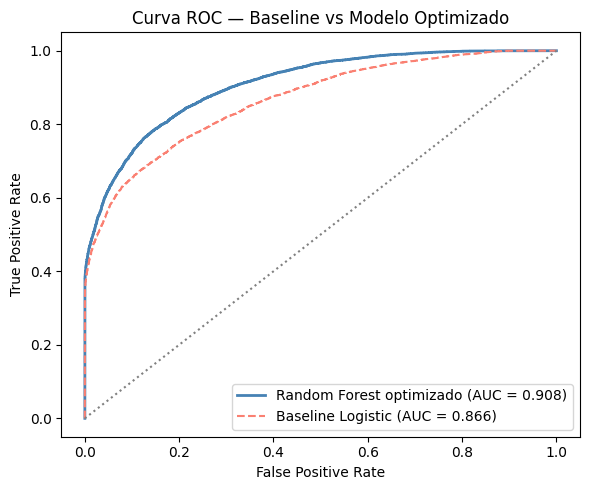

In [29]:
# Curva ROC — Modelo optimizado
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_proba_opt)
roc_auc_val = auc(fpr_opt, tpr_opt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_opt, tpr_opt, color="steelblue", lw=2,
         label=f"Random Forest optimizado (AUC = {roc_auc_val:.3f})")
plt.plot(fpr_log, tpr_log, color="salmon", lw=1.5, linestyle="--",
         label=f"Baseline Logistic (AUC = {roc_auc_log:.3f})")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Baseline vs Modelo Optimizado")
plt.legend()
plt.tight_layout()
plt.show()

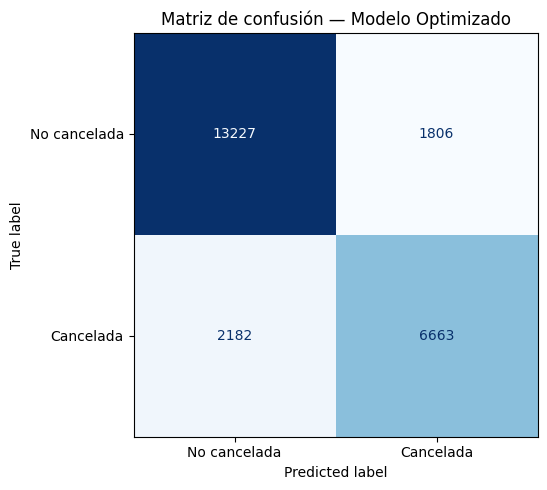

Verdaderos Negativos (TN) :  13227  — Reservas no canceladas correctamente predichas
Falsos Positivos    (FP) :   1806  — Reservas predichas como canceladas que no se cancelaron
Falsos Negativos    (FN) :   2182  — Cancelaciones no anticipadas por el modelo
Verdaderos Positivos (TP) :   6663  — Cancelaciones correctamente identificadas


In [30]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=["No cancelada", "Cancelada"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Matriz de confusión — Modelo Optimizado")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN) : {tn:>6}  — Reservas no canceladas correctamente predichas")
print(f"Falsos Positivos    (FP) : {fp:>6}  — Reservas predichas como canceladas que no se cancelaron")
print(f"Falsos Negativos    (FN) : {fn:>6}  — Cancelaciones no anticipadas por el modelo")
print(f"Verdaderos Positivos (TP) : {tp:>6}  — Cancelaciones correctamente identificadas")

---
## **Paso 14: Importancia de variables**

Análisis de las variables más influyentes en la predicción del modelo optimizado.

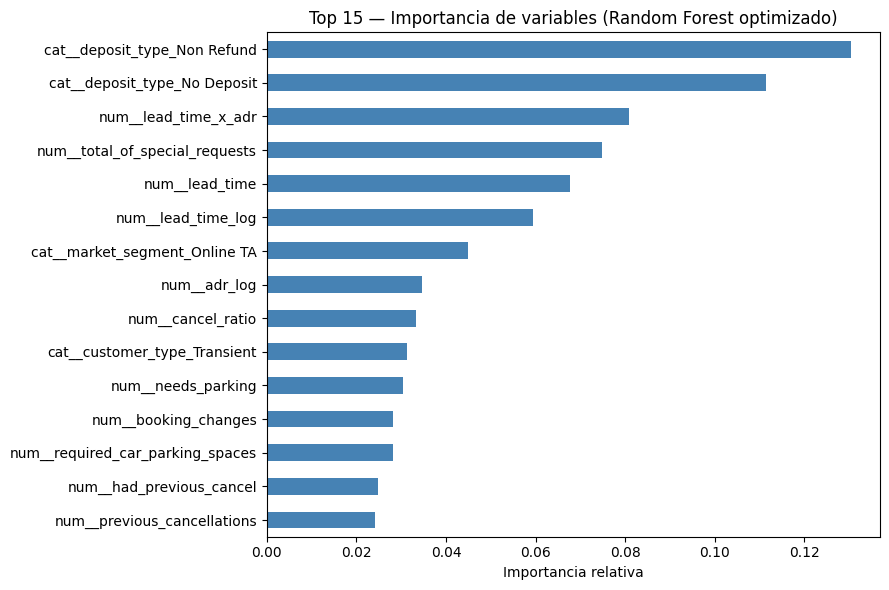


Top 15 variables más importantes:
cat__deposit_type_Non Refund        0.1304
cat__deposit_type_No Deposit        0.1115
num__lead_time_x_adr                0.0808
num__total_of_special_requests      0.0748
num__lead_time                      0.0678
num__lead_time_log                  0.0595
cat__market_segment_Online TA       0.0449
num__adr_log                        0.0347
num__cancel_ratio                   0.0333
cat__customer_type_Transient        0.0312
num__needs_parking                  0.0304
num__booking_changes                0.0282
num__required_car_parking_spaces    0.0281
num__had_previous_cancel            0.0248
num__previous_cancellations         0.0241


In [31]:
rf_final = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_final.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 15 — Importancia de variables (Random Forest optimizado)")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

print("\nTop 15 variables más importantes:")
print(feat_imp.head(15).round(4).to_string())

---
## **Paso 15: Tabla comparativa final — Baseline vs Modelo Optimizado**

In [32]:
from sklearn.metrics import f1_score

final_comparison = pd.DataFrame({
    "Modelo": [
        "Logistic Regression (baseline)",
        "Random Forest optimizado (final)"
    ],
    "Balanced Accuracy": [
        round(balanced_accuracy_score(y_test, y_pred_log), 4),
        round(test_bal, 4)
    ],
    "ROC-AUC": [
        round(roc_auc_log, 4),
        round(test_auc, 4)
    ],
    "F1 — Canceladas": [
        round(f1_score(y_test, y_pred_log), 4),
        round(f1_score(y_test, y_pred_opt), 4)
    ]
})

print("Comparativa final de métricas:")
final_comparison

Comparativa final de métricas:


,Modelo,Balanced Accuracy,ROC-AUC,F1 — Canceladas
0,Logistic Regression (baseline),0.7754,0.8662,0.7174
1,Random Forest optimizado (final),0.8166,0.9079,0.7697


**Interpretación de resultados:**

El modelo Random Forest optimizado mejora todas las métricas respecto al baseline:

- La **Balanced Accuracy** pasa de ~0.775 a ~0.82, indicando mejor equilibrio en la clasificación de ambas clases.
- El **ROC-AUC** aumenta de ~0.87 a ~0.91, demostrando una mayor capacidad discriminatoria.
- El **F1-score de cancelaciones** mejora de ~0.72 a ~0.77, lo que significa que el modelo detecta mejor la clase objetivo.

Desde el punto de vista del negocio:
- Los **falsos negativos** (cancelaciones no anticipadas) son el error más costoso: el hotel no puede prepararse para habitaciones vacías inesperadas.
- Los **falsos positivos** pueden llevar a acciones preventivas innecesarias, aunque tienen un impacto menor.
- Un ROC-AUC de ~0.91 confiere al modelo una **excelente capacidad** para apoyar decisiones de overbooking, políticas de cancelación y gestión de ocupación.

---
## **Paso 16: Guardado del modelo en formato joblib**

Se persisten tanto el modelo final (pipeline completo) como el baseline, en el directorio `src/models/`.

In [33]:
import joblib
import os
from datetime import datetime

# Crear directorio si no existe
os.makedirs("src/models", exist_ok=True)

# ── Guardar modelo final (Random Forest optimizado) ──
model_path = "src/models/random_forest_optimized.joblib"
joblib.dump(best_model, model_path)
print(f"Modelo optimizado guardado en: {model_path}")

# ── Guardar modelo baseline (Logistic Regression) ──
baseline_path = "src/models/logistic_regression_baseline.joblib"
joblib.dump(log_model, baseline_path)
print(f"Baseline guardado en: {baseline_path}")

# ── Verificación de ficheros ──
print("\nFicheros en src/models/:")
for f in os.listdir("src/models"):
    size_kb = os.path.getsize(f"src/models/{f}") / 1024
    print(f"  {f:<45}  {size_kb:>8.1f} KB")

print(f"\nFecha de generación: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Modelo optimizado guardado en: src/models/random_forest_optimized.joblib
Baseline guardado en: src/models/logistic_regression_baseline.joblib

Ficheros en src/models/:
  logistic_regression_baseline.joblib                 8.0 KB
  model.pkl                                           0.0 KB
  random_forest_optimized.joblib                  87861.1 KB

Fecha de generación: 2026-03-05 18:37:24


### Verificación: carga y predicción con el modelo guardado

In [34]:
# Carga y verificación de integridad
loaded_model = joblib.load("src/models/random_forest_optimized.joblib")

y_pred_loaded = loaded_model.predict(X_test)
bal_acc_loaded = balanced_accuracy_score(y_test, y_pred_loaded)

assert bal_acc_loaded == test_bal, "Las métricas del modelo cargado no coinciden con el original."

print(f"Modelo cargado correctamente.")
print(f"Balanced Accuracy (modelo cargado): {bal_acc_loaded:.4f}")
print(f"Coincide con el modelo original: {bal_acc_loaded == test_bal}")

Modelo cargado correctamente.
Balanced Accuracy (modelo cargado): 0.8166
Coincide con el modelo original: True


---
## Resumen del proyecto

| Paso | Descripción |
|------|-------------|
| 1 | Importación de librerías |
| 2 | Carga y exploración inicial de los datos |
| 3 | Limpieza: eliminación de columnas irrelevantes y data leakage |
| 4 | Análisis del target (`is_canceled`) |
| 5 | División Train / Test estratificada |
| 6 | Selección de variables |
| 7 | Feature Engineering (transformaciones log, agrupaciones, nuevas features) |
| 8 | Construcción del preprocesador (Pipeline) |
| 9 | Modelo baseline — Regresión Logística |
| 10 | Comparativa de modelos candidatos |
| 11 | Optimización de hiperparámetros — GridSearchCV |
| 12 | Evaluación Train vs Test (overfitting check) |
| 13 | Evaluación final en Test — métricas, ROC, matriz de confusión |
| 14 | Importancia de variables |
| 15 | Tabla comparativa final |
| 16 | Persistencia del modelo en `src/models/` (joblib) |

**Modelo final:** `Random Forest optimizado`  
**Ruta:** `src/models/random_forest_optimized.joblib`  
**Balanced Accuracy en test:** ~0.82 | **ROC-AUC en test:** ~0.91
